# TAREA 3: PRIMERA PARTE 
## Sandro Sotacuro Escobar
# Brecha Digital Territorial — Cusco, Perú
## Análisis Ráster Geoespacial
**Datos:** NASA VNL 2025 (EPSG:4326) · OSIPTEL Kernel Móvil 2019 50m (EPSG:32719)

---
## Paso 0 — Configuración del entorno

In [1]:
# Instalación de dependencias
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "rasterio", "numpy", "matplotlib", "scipy", "seaborn", "pandas",
                "--break-system-packages", "-q"], capture_output=True)

import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy
import seaborn as sns
import pandas as pd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_bounds
from scipy.ndimage import gaussian_filter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f"rasterio  {rasterio.__version__}")
print(f"numpy     {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"scipy     {scipy.__version__}")
print(f"seaborn   {sns.__version__}")
print(f"pandas    {pd.__version__}")

rasterio  1.5.0
numpy     2.4.4
matplotlib 3.10.9
scipy     1.17.1
seaborn   0.13.2
pandas    3.0.2


In [2]:
import os
# Rutas de datos — el notebook vive en notebooks/, los datos en data/
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('digital_divide_cusco.ipynb'))
BASE_DIR     = os.path.dirname(NOTEBOOK_DIR)   # sube un nivel: raster-digital-divide/
DATA_DIR     = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR   = os.path.join(BASE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

VNL_PATH  = os.path.join(DATA_DIR, 'VNL_cusco_2025.tif')
CONN_PATH = os.path.join(DATA_DIR, 'kernel_cobmovil2019_50m.tif')

# Verificar existencia
for p in [VNL_PATH, CONN_PATH]:
    status = '✓' if os.path.exists(p) else '✗ FALTA'
    print(f"{status}  {p}")

✓  d:\Data_science_Python_2026\raster-digital-divide\data\VNL_cusco_2025.tif
✓  d:\Data_science_Python_2026\raster-digital-divide\data\kernel_cobmovil2019_50m.tif


---
## Paso 1 — Carga e inspección de rásteres

In [3]:
def inspect_raster(path, label):
    """Imprime metadatos completos de un ráster."""
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        res_x, res_y = src.res
        # Resolución aproximada en km (1° ≈ 111 km en ecuador)
        res_km_x = abs(res_x) * 111
        res_km_y = abs(res_y) * 111

        # Máscara de píxeles válidos
        if nodata is not None:
            valid_mask = ~np.isclose(data, nodata, rtol=1e-5, atol=1e30)
        else:
            valid_mask = np.isfinite(data)
        valid = data[valid_mask]

        print(f"{'='*55}")
        print(f" {label}")
        print(f"{'='*55}")
        print(f"  CRS              : {src.crs}")
        print(f"  Forma (alto×ancho): {src.height} × {src.width}")
        print(f"  Bandas            : {src.count}")
        print(f"  NoData            : {nodata}")
        print(f"  Tipo de dato      : {src.dtypes[0]}")
        print(f"  Extensión (bounds): {src.bounds}")
        print(f"  Resolución px     : {res_x:.6f}° × {res_y:.6f}°")
        print(f"  Resolución aprox  : {res_km_x:.3f} km × {res_km_y:.3f} km")
        print(f"  Píxeles válidos   : {valid_mask.sum():,}")
        print(f"  Rango de valores  : [{valid.min():.6f}, {valid.max():.6f}]")
        print()
    return

inspect_raster(VNL_PATH,  'VNL_cusco_2025.tif  — Luces nocturnas NASA (nW·cm⁻²·sr⁻¹)')
inspect_raster(CONN_PATH, 'kernel_cobmovil2019_50m.tif — Densidad kernel cobertura móvil')

 VNL_cusco_2025.tif  — Luces nocturnas NASA (nW·cm⁻²·sr⁻¹)
  CRS              : EPSG:4326
  Forma (alto×ancho): 1081 × 961
  Bandas            : 1
  NoData            : None
  Tipo de dato      : float32
  Extensión (bounds): BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Resolución px     : 0.004167° × 0.004167°
  Resolución aprox  : 0.463 km × 0.463 km
  Píxeles válidos   : 1,038,841
  Rango de valores  : [-1.500000, 1254.614502]

 kernel_cobmovil2019_50m.tif — Densidad kernel cobertura móvil
  CRS              : EPSG:32719
  Forma (alto×ancho): 6116 × 7754
  Bandas            : 1
  NoData            : -3.4028234663852886e+38
  Tipo de dato      : float32
  Extensión (bounds): BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Resolución px     : 50.000000° × 50.000000°
  Resolución aprox  : 5550.000 km × 5550.000 km
  Píxeles válidos   : 47,423,464
  Rango de

---
## Paso 2: Reproyección y alineación de la cuadrícula

In [4]:
# --- Leer metadatos de VNL (referencia) ---
with rasterio.open(VNL_PATH) as src_vnl:
    vnl_crs       = src_vnl.crs
    vnl_transform = src_vnl.transform
    vnl_height    = src_vnl.height
    vnl_width     = src_vnl.width
    vnl_raw       = src_vnl.read(1).astype(np.float32)

# --- Reproyectar + remuestrear conectividad a cuadrícula VNL ---
conn_aligned = np.zeros((vnl_height, vnl_width), dtype=np.float32)

with rasterio.open(CONN_PATH) as src_conn:
    reproject(
        source      = rasterio.band(src_conn, 1),
        destination = conn_aligned,
        src_transform = src_conn.transform,
        src_crs       = src_conn.crs,
        src_nodata    = src_conn.nodata,
        dst_transform = vnl_transform,
        dst_crs       = vnl_crs,
        dst_nodata    = 0.0,
        resampling    = Resampling.bilinear
    )

print("✓ Reproyección y alineación completadas")
print(f"  VNL shape       : {vnl_raw.shape}")
print(f"  Conectividad shape: {conn_aligned.shape}")
assert vnl_raw.shape == conn_aligned.shape, "¡Shapes no coinciden!"
print("  Verificación de dimensiones: OK ✓")

✓ Reproyección y alineación completadas
  VNL shape       : (1081, 961)
  Conectividad shape: (1081, 961)
  Verificación de dimensiones: OK ✓


---
## Paso 3: Normalización robusta

In [5]:
def robust_normalize(arr, nodata_val=None, p_low=2, p_high=98):
    """
    Normalización percentil [p_low, p_high] → [0, 1].
    Reemplaza negativos y NoData con 0 antes de recortar.
    """
    out = arr.copy().astype(np.float32)
    # Reemplazar NoData
    if nodata_val is not None:
        out[np.isclose(out, nodata_val, rtol=1e-5, atol=1e28)] = 0.0
    # Reemplazar negativos
    out[out < 0] = 0.0
    # Reemplazar NaN/Inf
    out = np.where(np.isfinite(out), out, 0.0)

    plo = np.percentile(out[out > 0], p_low)  if np.any(out > 0) else 0.0
    phi = np.percentile(out[out > 0], p_high) if np.any(out > 0) else 1.0

    if phi == plo:
        return np.zeros_like(out)

    norm = (out - plo) / (phi - plo)
    norm = np.clip(norm, 0, 1)
    return norm


# Obtener nodata del ráster de conectividad
with rasterio.open(CONN_PATH) as src:
    conn_nodata = src.nodata

vnl_norm  = robust_normalize(vnl_raw,       nodata_val=None)
conn_norm = robust_normalize(conn_aligned,   nodata_val=conn_nodata)

for name, arr in [('VNL normalizado', vnl_norm), ('Conectividad normalizada', conn_norm)]:
    print(f"{name}:")
    print(f"  min={arr.min():.4f}  max={arr.max():.4f}  "
          f"media={arr.mean():.4f}  std={arr.std():.4f}")

VNL normalizado:
  min=0.0000  max=1.0000  media=0.0035  std=0.0414
Conectividad normalizada:
  min=0.0000  max=1.0000  media=0.0142  std=0.0807


---
## Paso 4 — Mapa 1: Luces nocturnas de VNL (original VS noramlizado)

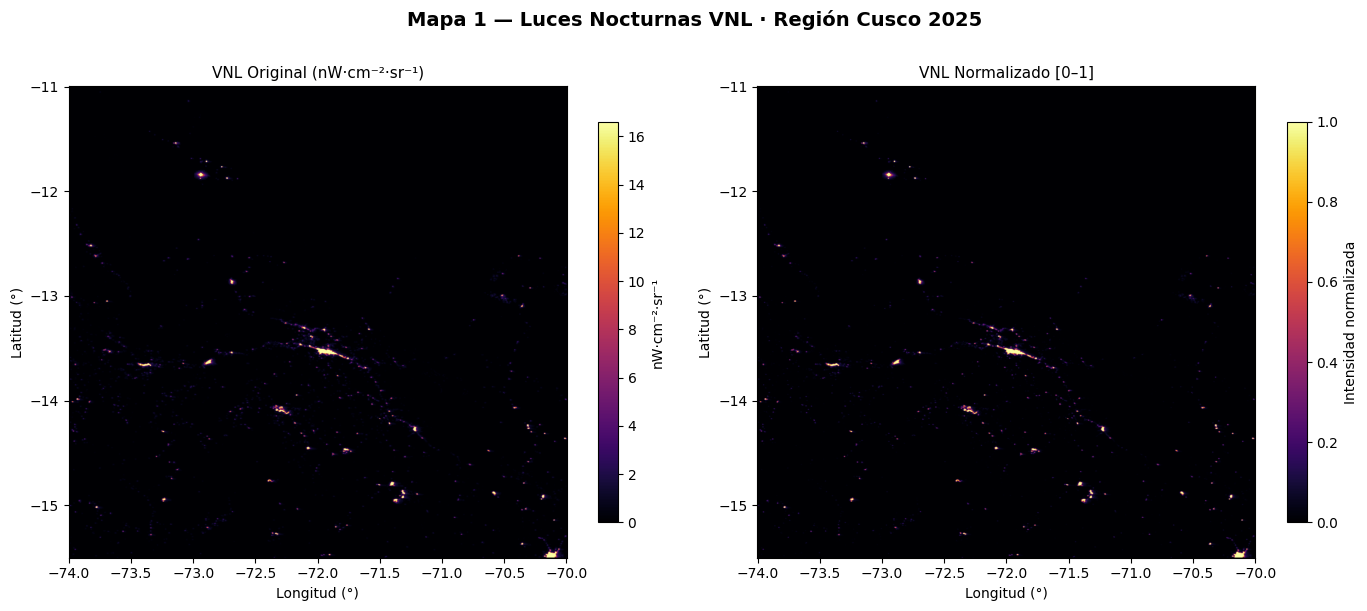

Observación:
Las zonas más brillantes (colores amarillo-blanco) corresponden a áreas urbanas
con mayor actividad humana nocturna: Cusco ciudad, Urubamba, Quillabamba.
Las zonas oscuras representan áreas rurales o de alta montaña con escasa
actividad económica o población dispersa.


In [7]:
with rasterio.open(VNL_PATH) as src:
    bounds = src.bounds
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mapa 1 — Luces Nocturnas VNL · Región Cusco 2025',
             fontsize=14, fontweight='bold', y=1.01)

# Original (clip p98 para visualización)
vnl_vis = np.clip(vnl_raw, 0, np.percentile(vnl_raw[vnl_raw > 0], 98))
im0 = axes[0].imshow(vnl_vis, cmap='inferno', extent=ext, origin='upper', aspect='auto')
axes[0].set_title('VNL Original (nW·cm⁻²·sr⁻¹)', fontsize=11)
axes[0].set_xlabel('Longitud (°)'); axes[0].set_ylabel('Latitud (°)')
plt.colorbar(im0, ax=axes[0], label='nW·cm⁻²·sr⁻¹', shrink=0.85)

# Normalizado
im1 = axes[1].imshow(vnl_norm, cmap='inferno', extent=ext, origin='upper',
                     vmin=0, vmax=1, aspect='auto')
axes[1].set_title('VNL Normalizado [0–1]', fontsize=11)
axes[1].set_xlabel('Longitud (°)'); axes[1].set_ylabel('Latitud (°)')
plt.colorbar(im1, ax=axes[1], label='Intensidad normalizada', shrink=0.85)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mapa1_vnl.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Observación:")
print("Las zonas más brillantes (colores amarillo-blanco) corresponden a áreas urbanas")
print("con mayor actividad humana nocturna: Cusco ciudad, Urubamba, Quillabamba.")
print("Las zonas oscuras representan áreas rurales o de alta montaña con escasa")
print("actividad económica o población dispersa.")

---
## Paso 5 — Mapa 2: Índice de Brecha Digital (IBD) e Índice de Exclusión Digital (EDT)

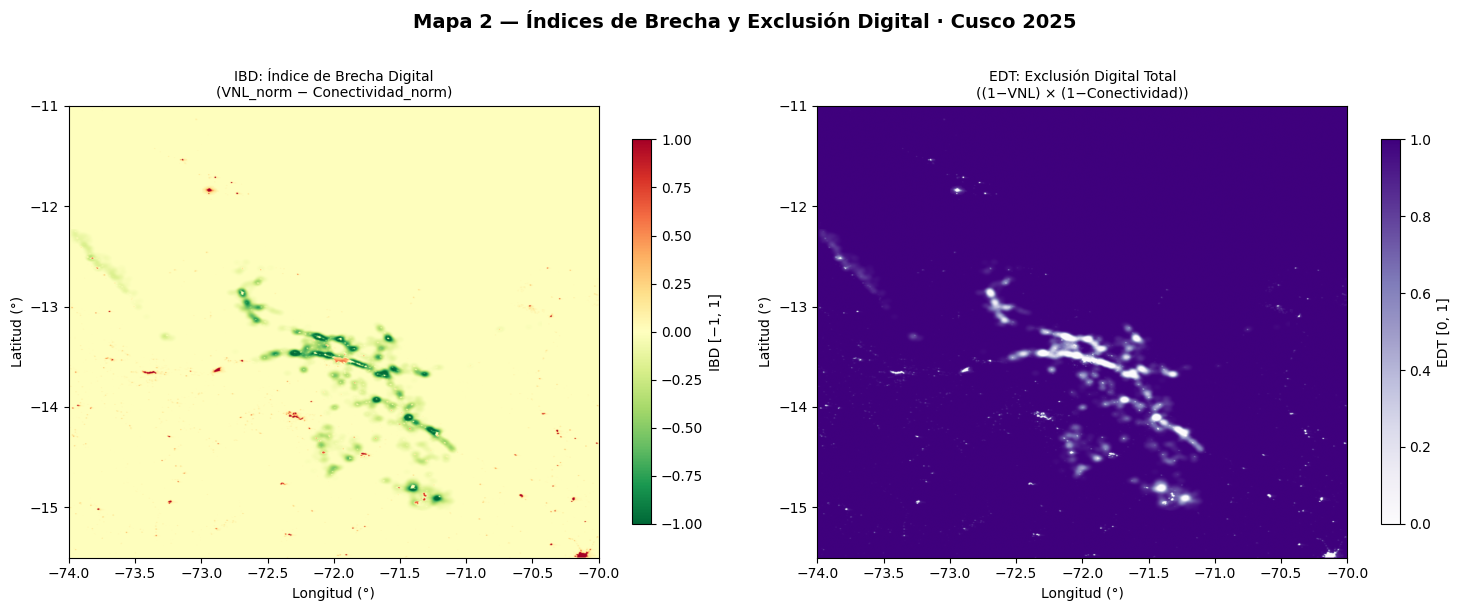

Interpretación IBD (RdYlGn_r):
  Valores rojos (IBD > 0): zonas con luz pero sin conectividad → brecha digital activa.
  Valores verdes (IBD < 0): zonas con buena conectividad relativa respecto a su luz.
  Píxeles con IBD > 0.3 (brecha alta): 1,943 (0.2%)
Interpretación EDT (Purples):
  Valores púrpura intensos = zonas sin luz NI conectividad = exclusión digital máxima.
  Píxeles con EDT > 0.8 (exclusión severa): 1,013,190 (97.5%)
  Estas zonas representan áreas rurales aisladas sin acceso digital de ningún tipo.


In [8]:
# Cálculo de índices
IBD = vnl_norm - conn_norm                         # rango [-1, 1]
EDT = (1 - vnl_norm) * (1 - conn_norm)              # rango [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Mapa 2 — Índices de Brecha y Exclusión Digital · Cusco 2025',
             fontsize=14, fontweight='bold', y=1.01)

# IBD
im0 = axes[0].imshow(IBD, cmap='RdYlGn_r', extent=ext, origin='upper',
                     vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('IBD: Índice de Brecha Digital\n(VNL_norm − Conectividad_norm)', fontsize=10)
axes[0].set_xlabel('Longitud (°)'); axes[0].set_ylabel('Latitud (°)')
cb0 = plt.colorbar(im0, ax=axes[0], label='IBD [−1, 1]', shrink=0.85)

# EDT
im1 = axes[1].imshow(EDT, cmap='Purples', extent=ext, origin='upper',
                     vmin=0, vmax=1, aspect='auto')
axes[1].set_title('EDT: Exclusión Digital Total\n((1−VNL) × (1−Conectividad))', fontsize=10)
axes[1].set_xlabel('Longitud (°)'); axes[1].set_ylabel('Latitud (°)')
cb1 = plt.colorbar(im1, ax=axes[1], label='EDT [0, 1]', shrink=0.85)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mapa2_ibd_edt.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación IBD (RdYlGn_r):")
print(f"  Valores rojos (IBD > 0): zonas con luz pero sin conectividad → brecha digital activa.")
print(f"  Valores verdes (IBD < 0): zonas con buena conectividad relativa respecto a su luz.")
print(f"  Píxeles con IBD > 0.3 (brecha alta): {(IBD > 0.3).sum():,} ({(IBD > 0.3).mean()*100:.1f}%)")

print("Interpretación EDT (Purples):")
print("  Valores púrpura intensos = zonas sin luz NI conectividad = exclusión digital máxima.")
print(f"  Píxeles con EDT > 0.8 (exclusión severa): {(EDT > 0.8).sum():,} ({(EDT > 0.8).mean()*100:.1f}%)")
print("  Estas zonas representan áreas rurales aisladas sin acceso digital de ningún tipo.")

---
## Paso 6 — Mapa 3: Prioridad de intervención

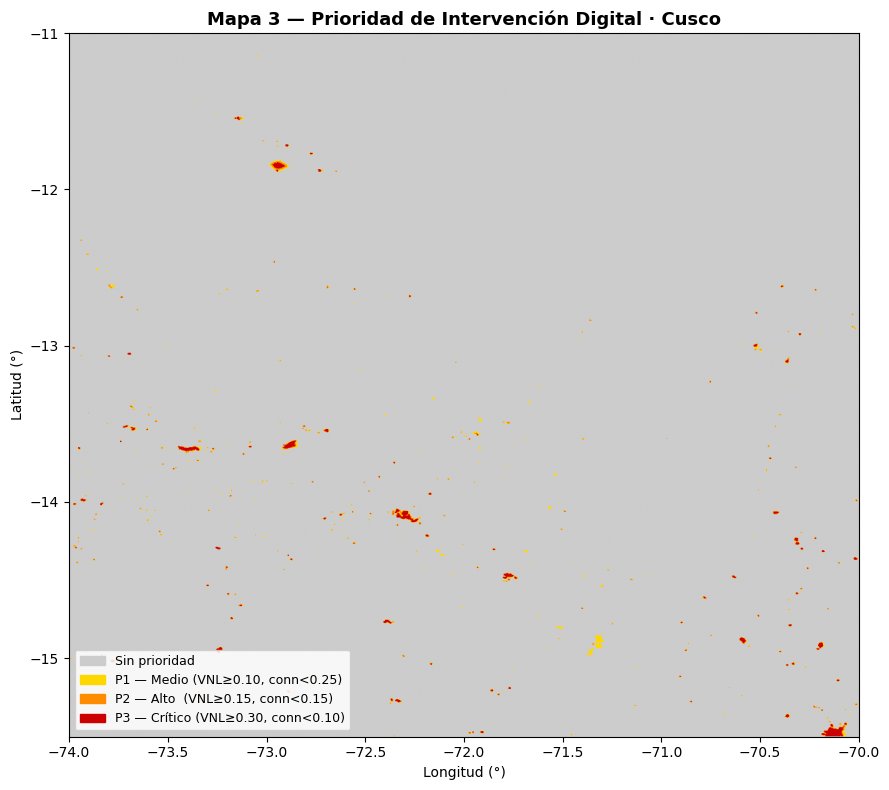

Estadísticas por nivel de prioridad:
  Sin prioridad            : 1,034,415 px  ( 99.6% del área total)
  P1 — Medio               :    1,570 px  (  0.2% del área total)
  P2 — Alto                :    1,267 px  (  0.1% del área total)
  P3 — Crítico             :    1,589 px  (  0.2% del área total)


In [9]:
# Clasificar prioridades
priority = np.zeros(vnl_norm.shape, dtype=np.uint8)

# P1 (Medio): VNL >= 0.10 y conn < 0.25
priority[(vnl_norm >= 0.10) & (conn_norm < 0.25)] = 1
# P2 (Alto): VNL >= 0.15 y conn < 0.15  (sobreescribe P1 donde aplica)
priority[(vnl_norm >= 0.15) & (conn_norm < 0.15)] = 2
# P3 (Crítico): VNL >= 0.30 y conn < 0.10  (sobreescribe P2 donde aplica)
priority[(vnl_norm >= 0.30) & (conn_norm < 0.10)] = 3

# Paleta
cmap_priority = matplotlib.colors.ListedColormap(['#CCCCCC', '#FFD700', '#FF8C00', '#CC0000'])
bounds_p = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_p   = matplotlib.colors.BoundaryNorm(bounds_p, cmap_priority.N)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(priority, cmap=cmap_priority, norm=norm_p,
               extent=ext, origin='upper', aspect='auto')
ax.set_title('Mapa 3 — Prioridad de Intervención Digital · Cusco', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud (°)'); ax.set_ylabel('Latitud (°)')

legend_elements = [
    mpatches.Patch(color='#CCCCCC', label='Sin prioridad'),
    mpatches.Patch(color='#FFD700', label='P1 — Medio (VNL≥0.10, conn<0.25)'),
    mpatches.Patch(color='#FF8C00', label='P2 — Alto  (VNL≥0.15, conn<0.15)'),
    mpatches.Patch(color='#CC0000', label='P3 — Crítico (VNL≥0.30, conn<0.10)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mapa3_prioridad.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas por nivel
total_pixels = priority.size
print("Estadísticas por nivel de prioridad:")
labels = {0: 'Sin prioridad', 1: 'P1 — Medio', 2: 'P2 — Alto', 3: 'P3 — Crítico'}
for val, name in labels.items():
    count = (priority == val).sum()
    pct   = count / total_pixels * 100
    print(f"  {name:25s}: {count:>8,} px  ({pct:5.1f}% del área total)")

---
## Paso 7 — Mapa 4: Riesgo de exclusión social

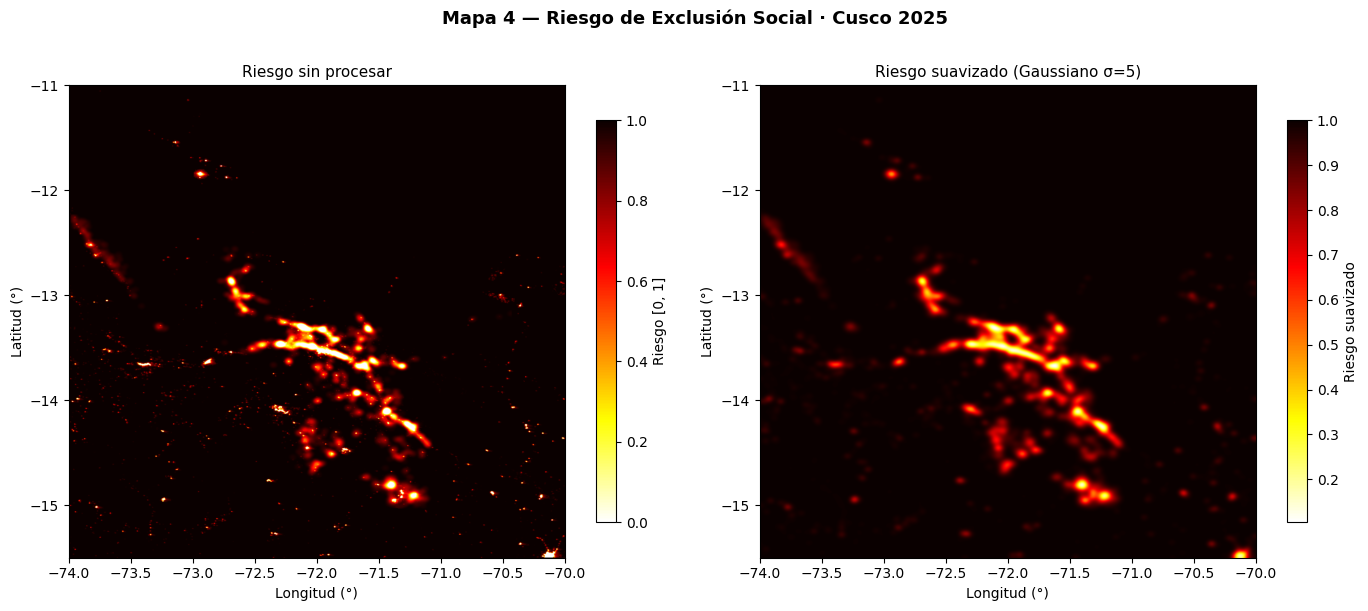

Umbrales de riesgo:
  Percentil 75: 1.0000  →  906,116 px (87.2%) con riesgo alto
  Percentil 90: 1.0000  →  906,116 px (87.2%) con riesgo muy alto


In [10]:
# Calcular puntuación de riesgo
risk_raw = EDT * (1 - vnl_norm)

# Normalizar a [0, 1]
r_min, r_max = risk_raw.min(), risk_raw.max()
risk_norm = (risk_raw - r_min) / (r_max - r_min) if r_max > r_min else risk_raw

# Suavizado gaussiano sigma=5
risk_smooth = gaussian_filter(risk_norm, sigma=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mapa 4 — Riesgo de Exclusión Social · Cusco 2025',
             fontsize=13, fontweight='bold', y=1.01)

im0 = axes[0].imshow(risk_norm, cmap='hot_r', extent=ext, origin='upper',
                     vmin=0, vmax=1, aspect='auto')
axes[0].set_title('Riesgo sin procesar', fontsize=11)
axes[0].set_xlabel('Longitud (°)'); axes[0].set_ylabel('Latitud (°)')
plt.colorbar(im0, ax=axes[0], label='Riesgo [0, 1]', shrink=0.85)

im1 = axes[1].imshow(risk_smooth, cmap='hot_r', extent=ext, origin='upper',
                     aspect='auto')
axes[1].set_title('Riesgo suavizado (Gaussiano σ=5)', fontsize=11)
axes[1].set_xlabel('Longitud (°)'); axes[1].set_ylabel('Latitud (°)')
plt.colorbar(im1, ax=axes[1], label='Riesgo suavizado', shrink=0.85)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mapa4_riesgo.png'), dpi=150, bbox_inches='tight')
plt.show()

p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
print(f"Umbrales de riesgo:")
print(f"  Percentil 75: {p75:.4f}  →  {(risk_norm >= p75).sum():,} px ({(risk_norm >= p75).mean()*100:.1f}%) con riesgo alto")
print(f"  Percentil 90: {p90:.4f}  →  {(risk_norm >= p90).sum():,} px ({(risk_norm >= p90).mean()*100:.1f}%) con riesgo muy alto")